# Symbol Dataset Augmentation Pipeline

All reusable logic lives in:
- **`augmentation_utils.py`** — pixel-level image transforms
- **`dataset_utils.py`** — I/O, splitting, balancing, plotting

This notebook only calls those functions and shows results.

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

from augmentation_utils import augment_image

from dataset_utils import (
    load_json,
    save_json,
    count_files,
    compute_targets,
    stratified_split,
    copy_images,
    group_by_class,
    next_available_index,
    complete_split,
    prepare_output_dir,
    plot_distribution,
    plot_distributions_grid,
)

## Configuration

Adjust `TOTAL_TRAIN` and `TEST_RATIO` here; per-class targets are computed automatically.

In [2]:
DATA_DIR   = "symbols_dataset"
OUT_DIR    = "augm_symbols_dataset"

TOTAL_TRAIN = 10000   # desired total number of training images
TEST_RATIO  = 0.25   # fraction of the full dataset reserved for test (e.g. 0.10 = 10 %)

## 1 — Load original labels & count classes

In [3]:
labels      = load_json(os.path.join(DATA_DIR, "labels.json"))
num_classes = len(set(labels.values()))

print(f"Total images  : {len(labels)}")
print(f"Num classes   : {num_classes}")

Total images  : 1090
Num classes   : 15


## 2 — Compute per-class targets

In [4]:
TRAIN_TARGET, TEST_TARGET = compute_targets(
    num_classes=num_classes,
    total_train=TOTAL_TRAIN,
    test_ratio=TEST_RATIO,
)

print(f"Train target  : {TRAIN_TARGET} images/class  ({TRAIN_TARGET * num_classes} total)")
print(f"Test  target  : {TEST_TARGET}  images/class  ({TEST_TARGET  * num_classes} total)")
print(f"Effective test ratio : {TEST_TARGET / (TRAIN_TARGET + TEST_TARGET):.1%}")

Train target  : 666 images/class  (9990 total)
Test  target  : 222  images/class  (3330 total)
Effective test ratio : 25.0%


## 3 — Original dataset distribution

<Axes: title={'center': 'Original dataset'}, xlabel='Class', ylabel='Count'>

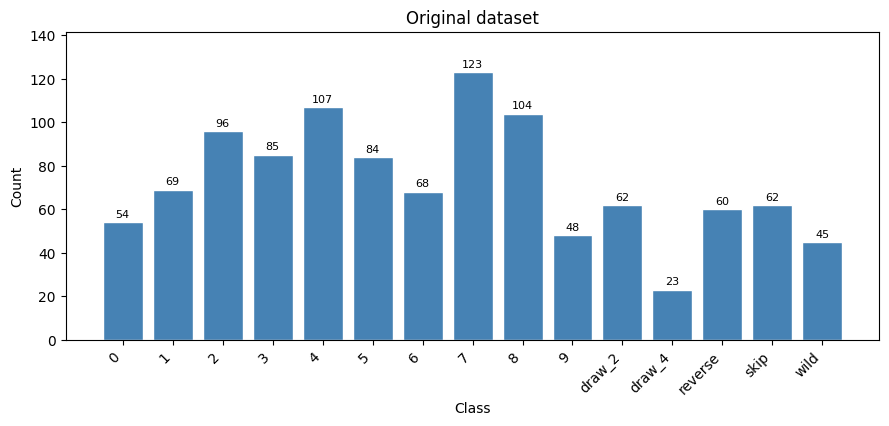

In [5]:
plot_distribution("Original dataset", labels)

## 4 — Stratified train / test split

Uses `TEST_RATIO` defined above to split each class.

In [6]:
train_labels, test_labels = stratified_split(labels, test_ratio=TEST_RATIO, seed=42)

print(f"Total : {len(labels)}")
print(f"Train : {len(train_labels)}")
print(f"Test  : {len(test_labels)}")

Total : 1090
Train : 822
Test  : 268


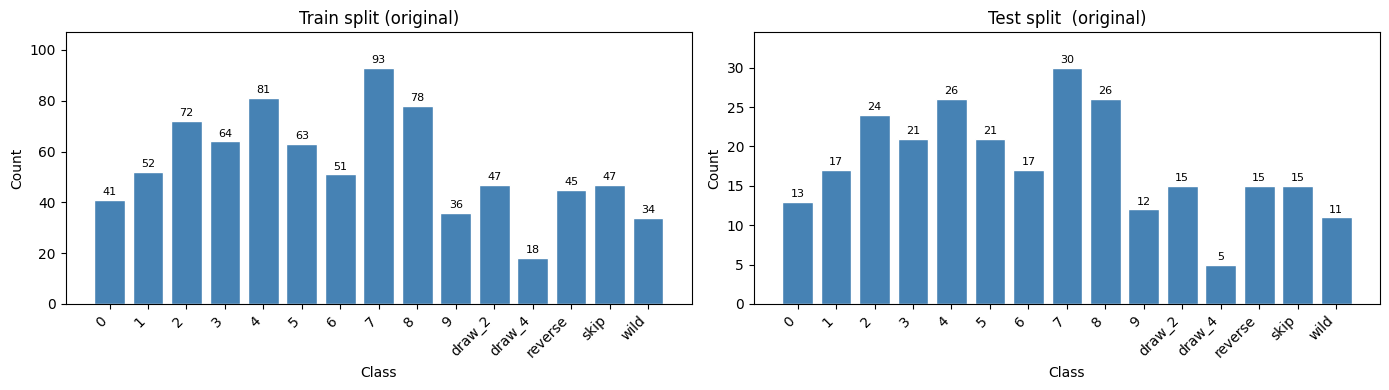

In [7]:
plot_distributions_grid([
    ("Train split (original)", train_labels),
    ("Test split  (original)", test_labels),
])

## 5 — Prepare output folder & copy originals

`prepare_output_dir` skips everything if the folder already contains images and split JSONs, so re-running this notebook is safe.

In [8]:
is_fresh_run = prepare_output_dir(OUT_DIR)

if is_fresh_run:
    # Save initial splits
    save_json(train_labels, os.path.join(OUT_DIR, "train.json"))
    save_json(test_labels,  os.path.join(OUT_DIR, "test.json"))

    # Copy original images
    all_images = list(train_labels.keys()) + list(test_labels.keys())
    copy_images(all_images, src_dir=DATA_DIR, dst_dir=OUT_DIR)

    orig_images, _ = count_files(DATA_DIR)
    aug_images,  _ = count_files(OUT_DIR)
    print(f"Original dataset : {orig_images} images")
    print(f"Output folder    : {aug_images}  images copied")
else:
    # Reload existing splits from disk
    train_labels = load_json(os.path.join(OUT_DIR, "train.json"))
    test_labels  = load_json(os.path.join(OUT_DIR, "test.json"))
    print("Loaded existing splits from disk.")

Copying original images: 100%|██████████| 1090/1090 [00:01<00:00, 636.37it/s]


Original dataset : 1090 images
Output folder    : 1090  images copied


## 6 — Visualise augmentation examples

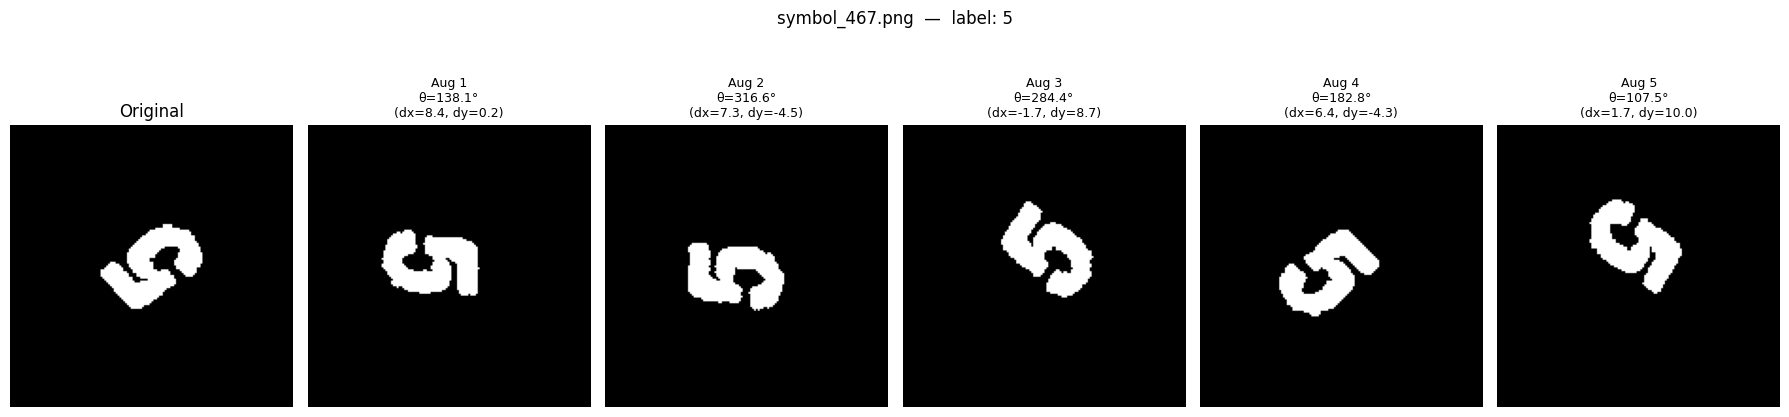

In [9]:
sample_img_name = list(train_labels.keys())[0]
img = Image.open(os.path.join(DATA_DIR, sample_img_name)).convert("RGB")

fig, axes = plt.subplots(1, 6, figsize=(18, 5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(5):
    aug, angle, tx, ty = augment_image(img)
    axes[i + 1].imshow(aug, cmap="gray")
    axes[i + 1].set_title(
        f"Aug {i+1}\nθ={angle:.1f}°\n(dx={tx:.1f}, dy={ty:.1f})",
        fontsize=9
    )
    axes[i + 1].axis("off")

plt.suptitle(f"{sample_img_name}  —  label: {train_labels[sample_img_name]}")
plt.tight_layout()
plt.show()

## 7 — Balance both splits by augmentation

Each class is brought up to `TRAIN_TARGET` / `TEST_TARGET` images.  
One progress bar per split; already-complete folders are skipped automatically.

In [10]:
if is_fresh_run:
    start_idx = next_available_index([train_labels, test_labels])

    new_train, start_idx = complete_split(
        split_labels=train_labels,
        target_count=TRAIN_TARGET,
        src_dir=DATA_DIR,
        out_dir=OUT_DIR,
        start_index=start_idx,
        split_name="TRAIN",
    )

    new_test, _ = complete_split(
        split_labels=test_labels,
        target_count=TEST_TARGET,
        src_dir=DATA_DIR,
        out_dir=OUT_DIR,
        start_index=start_idx,
        split_name="TEST",
    )

    save_json(new_train, os.path.join(OUT_DIR, "train.json"))
    save_json(new_test,  os.path.join(OUT_DIR, "test.json"))
    print("Saved updated train.json and test.json")
else:
    new_train = train_labels
    new_test  = test_labels
    print("Skipped augmentation — output folder already complete.")

Augmenting TEST: 100%|██████████| 3062/3062 [00:10<00:00, 286.86it/s]

Saved updated train.json and test.json


## 8 — Final distribution

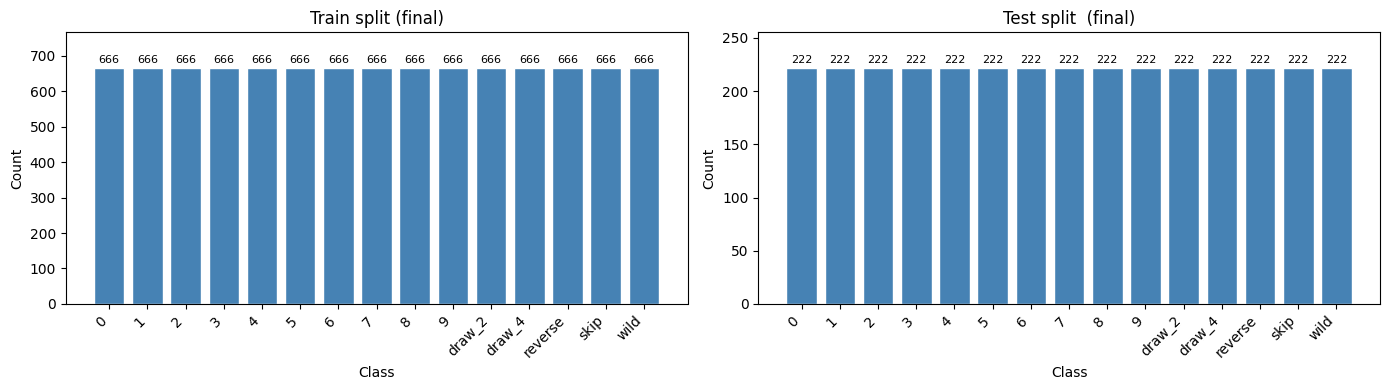

In [11]:
plot_distributions_grid([
    ("Train split (final)", new_train),
    ("Test split  (final)", new_test),
])